In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('StudentsPerformance.csv')

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [27]:
print("Shape:", df.shape)
print("\n Columns:")
print(df.columns)

Shape: (1000, 8)

 Columns:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


In [28]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


The dataset contains 1000 student records and 8 columns.
It includes demographic information and exam scores.
There are no missing values in the dataset.
Student performance is measured using math, reading and writing scores.
The dataset can be used to identify factors affecting academic performance.

In [29]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [30]:
parent_edu = df.groupby(
    'parental level of education'
)[['math score','reading score','writing score']].mean()

parent_edu.round(2)

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.88,70.93,69.90
bachelor's degree,69.39,73.00,73.38
high school,62.14,64.70,62.45
master's degree,69.75,75.37,75.68
some college,67.13,69.46,68.84
some high school,63.50,66.94,64.89


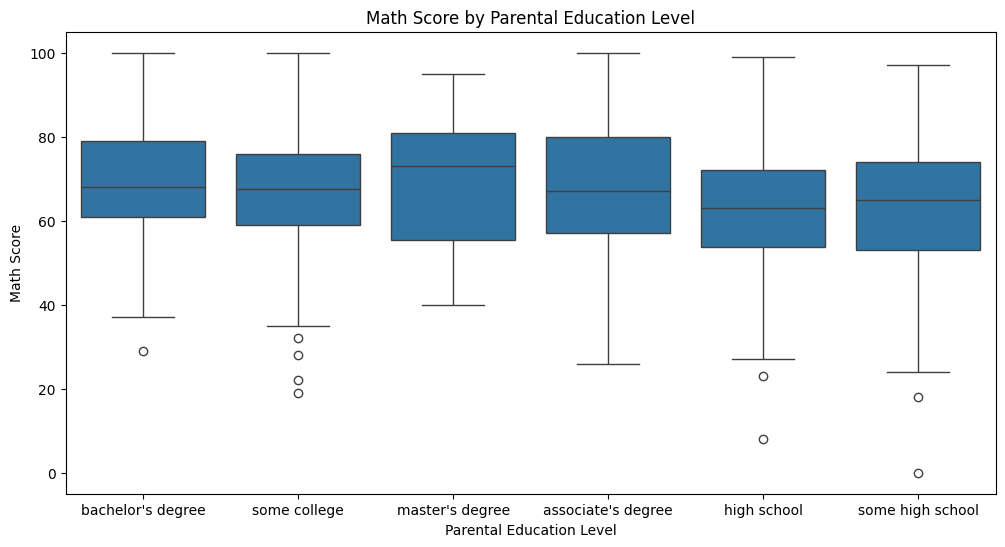

In [31]:
plt.figure(figsize=(12,6))

sns.boxplot(x='parental level of education',y='math score',data=df)

plt.title('Math Score by Parental Education Level')
plt.xlabel('Parental Education Level')
plt.ylabel('Math Score')
plt.show()


Students whose parents have bachelor's or master's degrees generally achieve higher scores.

In [32]:
#Test Preparation Impact

prep = df.groupby('test preparation course')[['math score','reading score','writing score']].mean()
prep.head()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


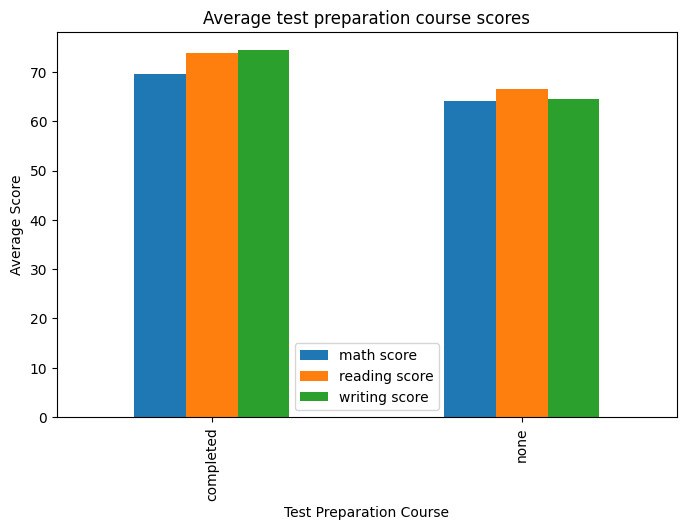

In [33]:
prep.plot(
    kind = 'bar',
    figsize=(8,5)
)

plt.title('Average test preparation course scores')
plt.xlabel('Test Preparation Course')
plt.ylabel('Average Score')
plt.show()

In [34]:
corr = df[['math score',
           'reading score',
           'writing score']].corr()

corr

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


Reading and writing scores are highly correlated, suggesting that language-related skills develop together.

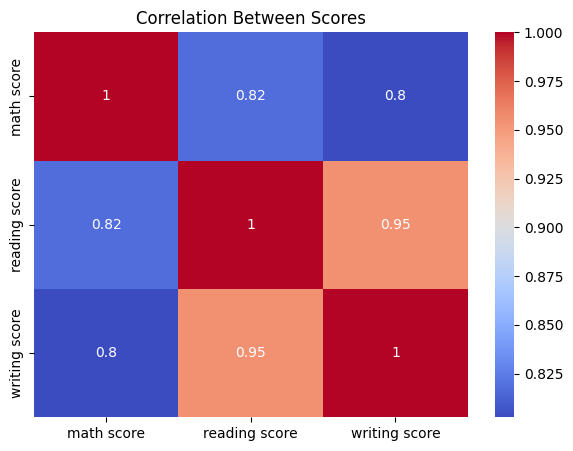

In [35]:
plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between Scores')
plt.show()

In [36]:
gender_scores = df.groupby('gender')[
    ['math score',
     'reading score',
     'writing score']
].mean()

gender_scores.round(2)

,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


Female students outperform males in language-based subjects, while males show stronger performance in mathematics.

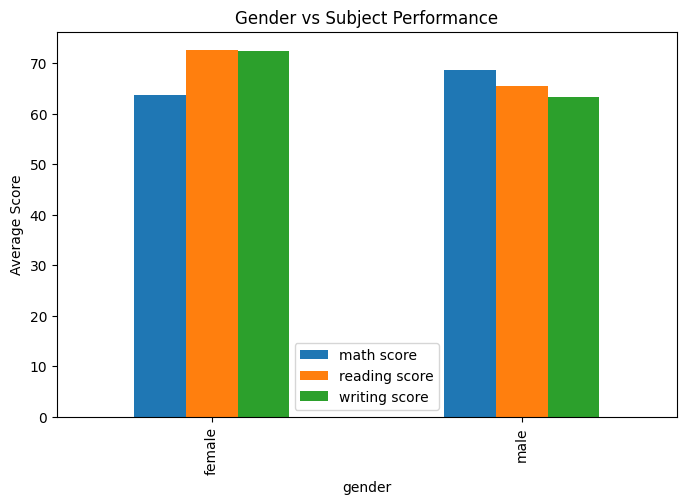

In [37]:
gender_scores.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Gender vs Subject Performance')
plt.ylabel('Average Score')
plt.show()

In [38]:
df['total_score'] = (
    df['math score']
    + df['reading score']
    + df['writing score']
)

df['total_score'].describe()

,total_score
count,1000.000000
mean,203.312000
std,42.771978
min,27.000000
25%,175.000000
50%,205.000000
75%,233.000000
max,300.000000


Student performance is relatively normally distributed around a mean total score of 203.

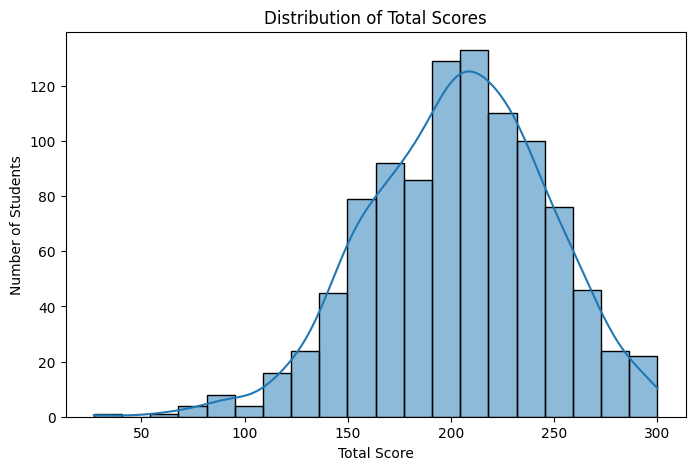

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['total_score'],
    bins=20,
    kde=True
)

plt.title('Distribution of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Number of Students')

plt.show()

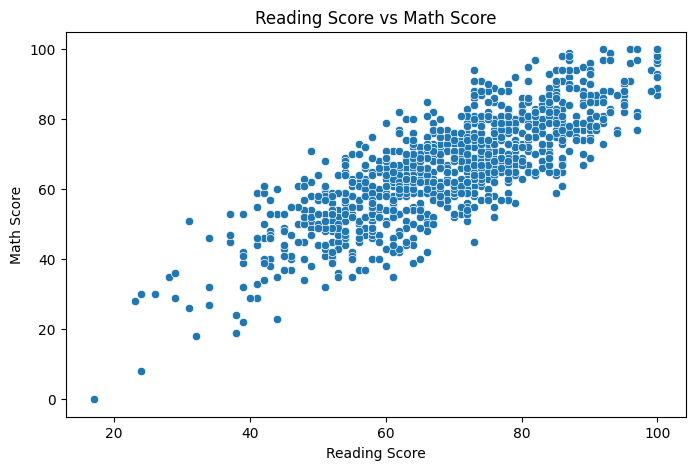

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='reading score',
    y='math score',
    data=df
)

plt.title('Reading Score vs Math Score')
plt.xlabel('Reading Score')
plt.ylabel('Math Score')

plt.show()

In [41]:
#A student is "At Risk" if any subject score is below 5
df['at_risk'] = (
    (df['math score'] < 50) |
    (df['reading score'] < 50) |
    (df['writing score'] < 50)
)

In [42]:
df['at_risk'].value_counts()

,count
at_risk,
False,812
True,188


In [43]:
risk_gender = df.groupby('gender')['at_risk'].mean()*100

risk_gender.round(2)

,at_risk
gender,
female,17.18
male,20.54


In [44]:
risk_prep = df.groupby(
    'test preparation course'
)['at_risk'].mean()*100

risk_prep.round(2)

,at_risk
test preparation course,
completed,10.06
none,23.68


Students who did not complete the test preparation course are more than twice as likely to be at risk compared to students who completed it.

In [45]:
risk_summary = pd.DataFrame({
    'Metric':['Total Students','At-Risk Students','At-Risk Percentage'],
    'Value':[1000,188,'18.8%']
})

risk_summary

,Metric,Value
0,Total Students,1000
1,At-Risk Students,188
2,At-Risk Percentage,18.8%


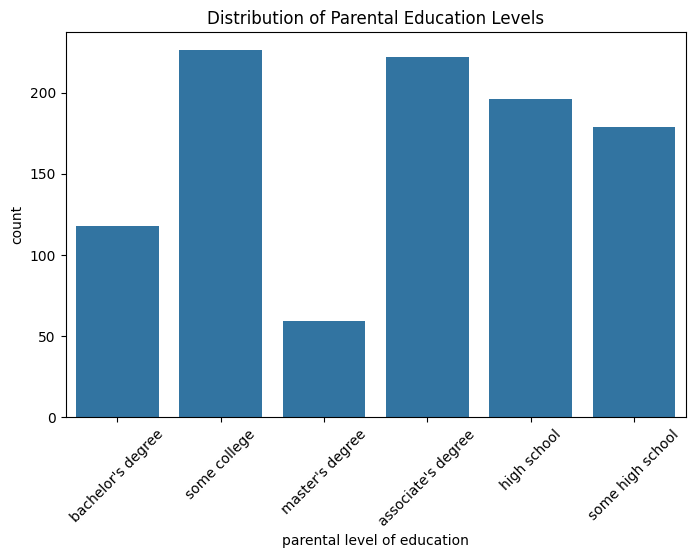

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='parental level of education',
    data=df
)

plt.title('Distribution of Parental Education Levels')
plt.xticks(rotation=45)

plt.show()

# Conclusion

The analysis revealed that parental education level and participation in test preparation courses significantly influence student performance. Reading and writing scores were strongly correlated, while gender differences were observed across subjects. Approximately 18.8% of students were identified as academically at risk, highlighting the need for targeted intervention programs.
